In [1]:
import torch

import sys
sys.path.append('../src')
sys.path.append('/shared_data0/weiqiuy/api_keys')
from data_utils import get_nsf_data_proc
from model_utils import get_model
from eval_utils import Metrics, evaluate_model

ROOT_DIR = '/shared_data0/weiqiuy/nsf-awards'
debug = True

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


# Eval

In [3]:
from unsloth import FastLanguageModel

# model_name = 'unsloth/Qwen2.5-7B'
# model_name = 'unsloth/Meta-Llama-3.1-8B-Instruct'
# model_name = '../models/lora_model_mistral-7b-instruct-v0.3_r128_la64_lr1e-05_e3_s-1_wu100_bs2_schlinear_optadamw_8bit_emb_lm_emb_lm'
# model_name = '../models/lora_model_mistral-7b-instruct-v0.3.technontech2claims_instruct_user_assistant.r128_la64_lr1e-05_e3_s-1_wu100_bs2_schlinear_optadamw_8bit_emb_lm'
# model_name = '../models/lora_model_Qwen2.5-7B-Instruct.technontech2claims_instruct.r128_la64_lr1e-05_e3_s-1_wu100_bs2_schlinear_optadamw_8bit_emb_lm'
model_name = '../models/lora_model_mistral-7b-instruct-v0.3.technontech2ip_instruct_user_assistant.r128_la64_lr1e-05_e3_s-1_wu100_bs2_schlinear_optadamw_8bit_emb_lm'

# model_name = 'NousResearch/Hermes-2-Theta-Llama-3-8B'

max_seq_length = 2048
load_in_4bit = True
dtype = None
model, tokenizer = FastLanguageModel.from_pretrained(
        model_name = model_name,
        max_seq_length = max_seq_length,
        dtype = dtype,
        load_in_4bit = load_in_4bit,
        # token = "hf_...", # use one if using gated models like meta-llama/Llama-2-7b-hf
    )
FastLanguageModel.for_inference(model);
# model, tokenizer = get_model(model_name, mode='eval')

# model_name_lora = f'{ROOT_DIR}/models/lora_model_{model_name.split("/")[1]}'
# model_lora, tokenizer = get_model(model_name_lora, mode='eval')

==((====))==  Unsloth 2025.1.7: Fast Mistral patching. Transformers: 4.48.1.
   \\   /|    GPU: NVIDIA A100 80GB PCIe. Max memory: 79.254 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.4.0+cu118. CUDA: 8.0. CUDA Toolkit: 11.8. Triton: 3.0.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.27.post2+cu118. FA2 = False]
 "-____-"     Free Apache license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Unsloth 2025.1.7 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


In [4]:
train_dataset, val_dataset, test_dataset = get_nsf_data_proc(ROOT_DIR, 
                                                             tokenizer, 
                                                             mode='technontech2ip_instruct_user_assistant',
                                                            eval_mode=True)

Train dataset keys: dict_keys(['award_id', 'technical_abstract', 'non_technical_abstract', 'verifiable_claims', 'investigation_proposals', 'award_year', 'division', 'directorate', 'title', 'publications'])
Validation dataset keys: dict_keys(['award_id', 'technical_abstract', 'non_technical_abstract', 'verifiable_claims', 'investigation_proposals', 'award_year', 'division', 'directorate', 'title', 'publications'])
Test dataset keys: dict_keys(['award_id', 'technical_abstract', 'non_technical_abstract', 'verifiable_claims', 'investigation_proposals', 'award_year', 'division', 'directorate', 'title', 'publications'])


Map:   0%|          | 0/8641 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [5]:
val_dataset[0]

{'award_id': 9312947,
 'technical_abstract': 'Research will be carried out to develop a fundamental  understanding of conventional and low temperature metalorganic  chemical vapor epitaxial materials growth and novel device  processing techniques for wide-bandgap III-V compound  semiconductors in the system consisting of the AlGaInN quaternary  and related ternary and binary alloys.  Lattice-matched and  intentionally lattice-mismatched heteroepitaxial heterostructures  will be grown in this materials system using both low-pressure  metalorganic chemical vapor deposition, and low-temperature  epitaxial growth by flow-rate modulation.  In addition, this  program will study the fundamental structural, electronic, and  optical materials properties, as well as the heterojunction band  alignments of these materials.',
 'non_technical_abstract': 'The primary goal of this program is to develop a  fundamental-understanding of the epitaxial growth, processing,  and properties of wide bandgap se

In [6]:
idx = 5
inputs = tokenizer(val_dataset[idx]['text'], return_tensors= 'pt').to('cuda')
outputs = model.generate(**inputs, max_new_tokens = 500, use_cache = True)

In [7]:
pred = tokenizer.decode(outputs[0]).replace(val_dataset[idx]['text'], '').strip()
pred

'<s> INVESTIGATION PROPOSALS:```json\n["Conduct research on giant magnetoresistance spin valves", "Investigate exchange anisotropy films", "Study magneto-optical multilayers", "Research giant magnetostriction thin films and multilayers", "Examine magnetic shape memory alloy bulk, thin films, and multilayers", "Develop materials for ballistic magnetoresistance", "Enhance collaborative research in magnetic materials", "Provide opportunities for research and student training in magnetic materials", "Conduct hands-on training for graduate, undergraduate, and high school students", "Offer laboratory experience for undergraduates", "Provide access to the new equipment for other researchers at SUNY-Buffalo pursuing research and education in magnetic materials"]\n```</s>'

In [9]:
from text_utils import text2json
from claims_utils import compare_claims
from tqdm.auto import tqdm

pred_ip = text2json(pred)
gold_ip = val_dataset[idx]['investigation_proposals']



In [18]:
pred_ip =['Conduct research on giant magnetoresistance spin valves',
  'Investigate exchange anisotropy films',
  'Study magneto-optical multilayers. Research giant magnetostriction thin films and multilayers']

gold_ip =['Conduct research on giant magnetoresistance spin valves',
  'Study exchange anisotropy films',
  'Investigate magneto-optical multilayers']

pred_ip, gold_ip

(['Conduct research on giant magnetoresistance spin valves',
  'Investigate exchange anisotropy films',
  'Study magneto-optical multilayers. Research giant magnetostriction thin films and multilayers'],
 ['Conduct research on giant magnetoresistance spin valves',
  'Study exchange anisotropy films',
  'Investigate magneto-optical multilayers'])

In [21]:
system_prompt = "Check two investigation proposals p1 and p2, if p1 is supported by p2. If p2 includes all the investigations proposed by p1, but also includes additional proposals, then it should still be supported (YES). If not all proposed investigations by p1 is included in p2, or if p2 contains actions that conflict with actions in p1, then it should be unsupported (NO). Answer only as a YES or NO."
# If c2 includes all the evidences for c1, but also includes additional content, then it should still be supported (YES). If not all information of c1 is included in c2, or if c2 contains information that conflicts with information in c1, then it should be unsupported (NO). 
scores = compare_claims(pred_ip, gold_ip, return_all=True, system_prompt=system_prompt, threshold=0.9)


In [22]:
scores

{'precision': 0.6666666666666666,
 'recall': 1.0,
 'fscore': 0.8,
 'precision_scores': [True, True, False],
 'recall_scores': [True, True, True],
 'precision_scores_logprob': [0.9999998063873693, 1.0, 1.0],
 'recall_scores_logprob': [0.9999996871837232, 1.0, 1.0],
 'precision_scores_all': [[True, False, False],
  [False, True, False],
  [False, False, False]],
 'recall_scores_all': [[True, False, False],
  [False, True, False],
  [False, False, True]],
 'precision_scores_completion_all': [['yes', 'no', 'no'],
  ['no', 'yes', 'no'],
  ['no', 'no', 'no']],
 'recall_scores_completion_all': [['yes', 'no', 'no'],
  ['no', 'yes', 'no'],
  ['no', 'no', 'yes']],
 'precision_scores_logprob_all': [[0.9999996871837232,
   0.9999996871837232,
   0.9999998063873693],
  [1.0, 0.9959288393248596, 1.0],
  [1.0, 1.0, 0.7772982680686182]],
 'recall_scores_logprob_all': [[0.9999995679801056,
   0.9999996871837232,
   0.9990887134795086],
  [1.0, 0.9998764455604927, 0.9999784691634502],
  [1.0, 1.0, 0.991

In [15]:
from diskcache import Cache

cache = Cache("/shared_data0/weiqiuy/cachedir")

@cache.memoize()
def f(x, y):
    # print('Running f({}, {})'.format(x, y))
    return x*x + y*y

In [17]:
import time

start = time.time()
for i in tqdm(range(100)):
    for j in tqdm(range(100)):
        f(i, j)
print(time.time() - start)

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [13]:
scores

{'precision': 1.0,
 'recall': 1.0,
 'fscore': 1.0,
 'precision_scores': [True, True],
 'recall_scores': [True, True],
 'precision_scores_logprob': [0.9999998063873693, 0.9999998063873693],
 'recall_scores_logprob': [0.9999998063873693, 0.9999998063873693],
 'precision_scores_all': [[True, False], [False, True]],
 'recall_scores_all': [[True, False], [False, True]],
 'precision_scores_completion_all': [['yes', 'no'], ['no', 'yes']],
 'recall_scores_completion_all': [['yes', 'no'], ['no', 'yes']],
 'precision_scores_logprob_all': [[0.9999995679801056, 0.9999998063873693],
  [0.9999998063873693, 0.99752716542212]],
 'recall_scores_logprob_all': [[0.9999995679801056, 0.9999998063873693],
  [0.9999998063873693, 0.9988302244702674]]}

# Eval

In [4]:
results = evaluate_model(model, tokenizer, test_dataset, debug=debug)
results_lora = evaluate_model(model_lora, tokenizer, test_dataset, debug=debug)

  0%|          | 0/2306 [00:00<?, ?it/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  0%|          | 0/2306 [00:00<?, ?it/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [24]:
import os
debug = True
save_dir = 'results/tech2nontech'
if debug:
    save_dir += '_debug'
os.makedirs(save_dir, exist_ok=True)
torch.save(results, os.path.join(save_dir, model_name.split('/')[-1] + '.pt'))
torch.save(results_lora, os.path.join(save_dir, model_name_lora.split('/')[-1] + '.pt'))

# Show results text

In [2]:
load_dir = '../results/technontech2ip'
if debug:
    load_dir += '_debug'

model_names = [
    "unsloth/mistral-7b-instruct-v0.3",
    "models/lora_model_mistral-7b-instruct-v0.3.technontech2ip_instruct_user_assistant.r128_la64_lr1e-05_e3_s-1_wu100_bs2_schlinear_optadamw_8bit_emb_lm",
    "unsloth/Qwen2.5-7B-Instruct",
    "models/lora_model_Qwen2.5-7B-Instruct.technontech2ip_instruct.r128_la64_lr1e-05_e3_s-1_wu100_bs2_schlinear_optadamw_8bit_emb_lm"
]

model_name_mapping = {
    'mistral': "unsloth/mistral-7b-instruct-v0.3",
    'mistral_lora': "models/lora_model_mistral-7b-instruct-v0.3.technontech2ip_instruct_user_assistant.r128_la64_lr1e-05_e3_s-1_wu100_bs2_schlinear_optadamw_8bit_emb_lm",
    'qwen': "unsloth/Qwen2.5-7B-Instruct",
    'qwen_lora': "models/lora_model_Qwen2.5-7B-Instruct.technontech2ip_instruct.r128_la64_lr1e-05_e3_s-1_wu100_bs2_schlinear_optadamw_8bit_emb_lm"
}

all_model_basenames = [model_name.split('/')[-1] for model_name in model_names]


In [3]:
import os
import json
from collections import defaultdict
from data_utils import load_jsonl

results_all = {}
for model_basename in all_model_basenames:
    with open(os.path.join(load_dir, model_basename + '.json'), 'rt') as input_file:
        results_all[model_basename] = json.load(input_file)
    # results_all[model_basename] = load_jsonl(os.path.join(load_dir, model_basename + '_preds.jsonl'))
    

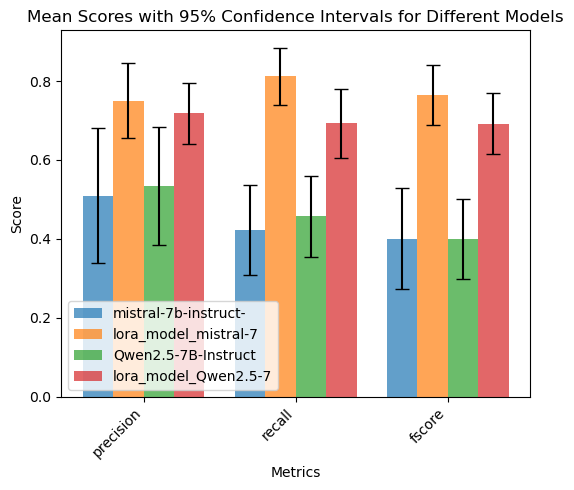

In [4]:
from vis_utils import aggregate_and_analyze, plot_grouped_bar_adjustable_width

results_all_aggr = {}
for key in results_all:
    aggr_results = aggregate_and_analyze(results_all[key])
    results_all_aggr[key] = aggr_results
    
# Running the function with your dataset
plot_grouped_bar_adjustable_width(results_all_aggr, save_path='figures/technontech2ip.pdf')

In [8]:
results_all.keys()

dict_keys(['mistral-7b-instruct-v0.3', 'lora_model_mistral-7b-instruct-v0.3.technontech2ip_instruct_user_assistant.r128_la64_lr1e-05_e3_s-1_wu100_bs2_schlinear_optadamw_8bit_emb_lm', 'Qwen2.5-7B-Instruct', 'lora_model_Qwen2.5-7B-Instruct.technontech2ip_instruct.r128_la64_lr1e-05_e3_s-1_wu100_bs2_schlinear_optadamw_8bit_emb_lm'])

In [9]:
for key in results_all.keys():
    print(key, len(results_all[key]))

mistral-7b-instruct-v0.3 20
lora_model_mistral-7b-instruct-v0.3.technontech2ip_instruct_user_assistant.r128_la64_lr1e-05_e3_s-1_wu100_bs2_schlinear_optadamw_8bit_emb_lm 20
Qwen2.5-7B-Instruct 20
lora_model_Qwen2.5-7B-Instruct.technontech2ip_instruct.r128_la64_lr1e-05_e3_s-1_wu100_bs2_schlinear_optadamw_8bit_emb_lm 20


In [10]:
import numpy as np

def aggregate_and_analyze_any(results):
    """
    Takes a list of result dicts and returns a dictionary of
    {metric_name: (mean, std)} pairs. 
    """
    # Prepare containers for each metric
    metrics = defaultdict(list)
    
    for res in results:
        for key, val in res.items():
            metrics[key].append(val)
    
    # Now compute mean and bootstrap std for each metric
    analysis = {}
    for metric_name, values in metrics.items():
        mean_val = np.mean(values)
        std_val = bootstrap_std(values, n_bootstrap=1000, seed=42)
        analysis[metric_name] = (mean_val, std_val)
    
    return analysis

In [11]:
from vis_utils import bootstrap_std, aggregate_and_analyze, plot_grouped_bar

results_all_aggr = {}
for key in results_all:
    aggr_results = aggregate_and_analyze_any(results_all[key])
    results_all_aggr[key] = aggr_results
    
results_all_aggr

{'mistral-7b-instruct-v0.3': {'precision': (0.5095238095238095,
   0.08534715746095711),
  'recall': (0.4231934731934732, 0.05870146686764159),
  'fscore': (0.40031828631436345, 0.06663087191522989)},
 'lora_model_mistral-7b-instruct-v0.3.technontech2ip_instruct_user_assistant.r128_la64_lr1e-05_e3_s-1_wu100_bs2_schlinear_optadamw_8bit_emb_lm': {'precision': (0.749897186147186,
   0.04916034573572272),
  'recall': (0.811882006882007, 0.03639357767919865),
  'fscore': (0.7641143321640552, 0.03832832865557359)},
 'Qwen2.5-7B-Instruct': {'precision': (0.5333730158730159, 0.0809287751841562),
  'recall': (0.4572015484515484, 0.05302085330970946),
  'fscore': (0.39964068484640036, 0.05086292493543894)},
 'lora_model_Qwen2.5-7B-Instruct.technontech2ip_instruct.r128_la64_lr1e-05_e3_s-1_wu100_bs2_schlinear_optadamw_8bit_emb_lm': {'precision': (0.7178388278388279,
   0.04110222508040769),
  'recall': (0.6929030691530691, 0.04531359463421363),
  'fscore': (0.6916527656621326, 0.03753562257552505)

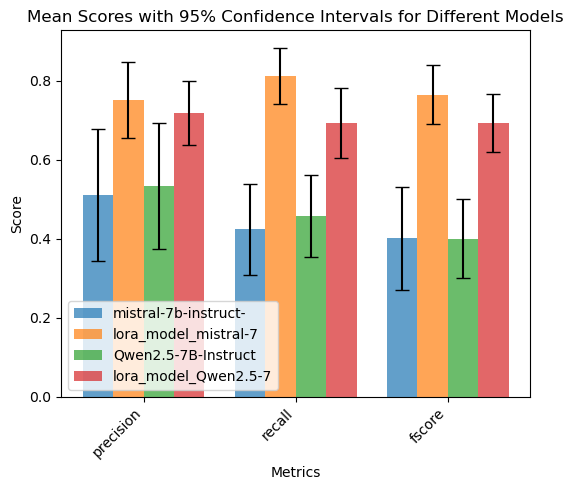

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import os  # Needed for saving the figure

def plot_grouped_bar_adjustable_width(results, save_path=None):
    """
    Given the results dictionary {model_name: {metric_name: (mean, std)}},
    create a grouped bar plot with error bars representing the 95% confidence intervals,
    adjusting the bar width dynamically based on the number of models.
    
    Note: Here we assume the provided 'std' is an estimate of the standard error,
    so the 95% CI is computed as 1.96 * std.
    """
    models = list(results.keys())
    metrics = list(next(iter(results.values())).keys())

    means = {metric: [results[model][metric][0] for model in models] for metric in metrics}
    stds = {metric: [results[model][metric][1] for model in models] for metric in metrics}

    x = np.arange(len(metrics))  # Label locations
    width = max(0.1, 0.8 / len(models))  # Dynamically adjust width

    fig, ax = plt.subplots(figsize=(5.5, 5))

    for i, model in enumerate(models):
        # Compute the 95% confidence interval margin as 1.96 * std (assuming std is the standard error)
        ci = [1.96 * stds[m][i] for m in metrics]
        ax.bar(x + i * width - (len(models) - 1) * width / 2,  # Center the bars
               [means[m][i] for m in metrics],
               width, 
               yerr=ci, capsize=5, label=model[:20], alpha=0.7)

    ax.set_xlabel('Metrics')
    ax.set_ylabel('Score')
    ax.set_title('Mean Scores with 95% Confidence Intervals for Different Models')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, rotation=45, ha='right')
    ax.legend()
    plt.tight_layout()
    
    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches='tight', pad_inches=0)
    
    plt.show()

# Running the function with your dataset
plot_grouped_bar_adjustable_width(results_all_aggr, save_path='figures/technontech2ip.pdf')


In [112]:
model_name = 'mistral_lora'
model_path = model_name_mapping[model_name]
idx = 0

def check_text(model_name, idx):
    pred = results_all['mistral-7b-instruct-v0.3'][0]['preds'][idx]
    technical_abstract = results_all['mistral-7b-instruct-v0.3'][0]['technical_abstracts'][idx]
    non_technical_abstract = results_all['mistral-7b-instruct-v0.3'][0]['non_technical_abstracts'][idx]

    print('--- technical_abstract ---')
    print(technical_abstract)
    print('--- pred ---')
    print(pred)
    print('--- non_technical_abstract ---')
    print(non_technical_abstract)
    
check_text(model_name, idx)

--- technical_abstract ---
The objective of the investigation is to study the glass-forming ranges, densities, glass transition temperatures, ionic conductivities, and infrared transmission spectra of sulfide glass systems. Alkali and silver sulfide, aluminum sulfide, and boron and phosphorous sulfide glasses will be prepared in controlled ambient conditions to eliminate oxygen and water vapor. The physical properties will be determined using direct current electrical conductivity, differential scanning calorimetry, Fourier Transform Infrared Spectroscopy, and nuclear magnetic resonance. The structure of these glasses will be compared to their oxide analogues.
--- pred ---
<s> The objective of the investigation is to study the properties of sulfide glasses, specifically focusing on their glass-forming ranges, densities, glass transition temperatures, ionic conductivities, and infrared transmission spectra. These glasses will be prepared in controlled laboratory conditions to minimize t

In [114]:
check_text('mistral_lora', 1)

--- technical_abstract ---
9306814  Yodh    This is an experimental program to develop and apply diffusing-  light probes to the study of the structure and dynamics of turbid  materials.  Experiments are planned to (1) investigate the  transport and fluctuation of light in colloidal crystals,  especially the effects of defects and structural correlations; (2)  apply these new spectroscopies to study the evolution more complex  turbid material such as slurries, sand piles, gels, microemulsions,  and foams; (3) explore the fundamental aspects of traveling waves  of light energy density that are produce when amplitude modulated  light sources are introduced into a turbid medium; and (4) continue  our studies of the dynamical and structural correlations in dense  colloidal suspensions of particles.  The knowledge gained by these  studies will improve our fundamental understanding of new kinds of  materials, will extend our knowledge of the properties of diffusing  light, and will lead to n

In [86]:
check_text('mistral_lora', 2)

--- technical_abstract ---
This award to the University of Toledo is for the acquisition of a Terahertz Spectroscopic Ellipsometer to measure optical properties and structure of materials over a range from 0.11 to 1.45 THz. Optical properties in this region are expected to be sensitive to vibrational modes and absorption due to free carriers; and spectroscopic ellipsometry can also be used to deduce layer thicknesses, interfacial formation, and gradients. In the THz regime, optical properties approach the DC limit, thus they can be used to extrapolate electrical properties of materials (carrier concentration, mobility, etc.). The ability to extract electrical properties from a non-contacting optical measurement is particularly attractive for probing materials in device structures or where traditional electrical characterization is difficult including photovoltaic materials and devices; microbolometer materials for uncooled infrared sensors; structured materials including nanoparticle f

In [87]:
check_text('mistral', 3)

--- technical_abstract ---
9624603  Tuominen    This  experimental research project is designed to  help  advance the  science  and  technology  of  nanostructure  single-electron devices.  The  first  research objective of  this  project  is  to utilize single-electron  device  techniques to explore and understand several key issues in  mesoscopic superconductivity:  even-odd  electron  number  physics, the physics of macroscopic quantum variables, and  coherent charge transport through superconducting-normal  metal interfaces. The second objective  is to   investigate  --  and  precisely  control  --   the   quantum interaction  `etween   single-electron   devices    and    their  electromagnetic environment by utilizing the powerful  techniques of cavity quantum electrodynamics. The 60  nanometer-scale devices used   in  this  work  will  be  fabricated  using  electron-beam lithography, thin-film  metallization, and microelectronics  clean room  techniques.  An ultrahigh vacuum thi

In [88]:
len(results_all['mistral-7b-instruct-v0.3'][0]['technical_abstracts'])

20

In [34]:
len(results_all['mistral-7b-instruct-v0.3'][0]['non_technical_abstracts'])

20

In [14]:
len(results_all[os.path.basename(model_names[1])])

157

# Show results

In [97]:
load_dir = '../results/tech2nontech'
if debug:
    load_dir += '_debug'
# model_names = [
#     'unsloth/Qwen2.5-7B',
#     'unsloth/Meta-Llama-3.1-8B'
# ]
# model_names=[
#   "unsloth/mistral-7b-instruct-v0.3",
#   "models/lora_model_mistral-7b-instruct-v0.3_r16_la16_lr1e-05_e5_s-1_wu100_bs2_schlinear_optadamw_8bit",
#   # "models/lora_model_mistral-7b-instruct-v0.3_r128_la64_lr1e-05_e5_s-1_wu100_bs2_schlinear_optadamw_8bit_emb_lm",
#   # "models/lora_model_mistral-7b-instruct-v0.3_r128_la64_lr1e-05_e3_s-1_wu100_bs2_schlinear_optadamw_8bit_emb_lm",
#   "models/lora_model_mistral-7b-instruct-v0.3_lr5e-05_e3_s-1_wu100_bs2_schlinear_optadamw_8bit",
#   "unsloth/Meta-Llama-3.1-8B-Instruct",
#     "models/lora_model_Meta-Llama-3.1-8B-Instruct_r128_la64_lr1e-05_e3_s-1_wu100_bs2_schlinear_optadamw_8bit_emb_lm_emb_lm"
# ]

model_names = [
    "unsloth/Meta-Llama-3.1-8B-Instruct",
    "models/lora_model_Meta-Llama-3.1-8B-Instruct_r128_la64_lr1e-05_e3_s-1_wu100_bs2_schlinear_optadamw_8bit_emb_lm_emb_lm",
    "unsloth/mistral-7b-instruct-v0.3",
    "models/lora_model_mistral-7b-instruct-v0.3_r128_la64_lr1e-05_e3_s-1_wu100_bs2_schlinear_optadamw_8bit_emb_lm_emb_lm",
    "unsloth/Qwen2.5-7B-Instruct",
    "models/lora_model_Qwen2.5-7B-Instruct_r128_la64_lr1e-05_e3_s-1_wu100_bs2_schlinear_optadamw_8bit_emb_lm_emb_lm"
]

all_model_basenames = [model_name.split('/')[-1] for model_name in model_names]

# lora_model_names = [f'{ROOT_DIR}/models/lora_model_{model_name.split("/")[1]}' 
#                     for model_name in model_names]

# all_model_basenames = [model_name.split('/')[-1] for model_name in model_names] + \
#     [model_name.split('/')[-1] for model_name in lora_model_names]

In [98]:
all_model_basenames

['Meta-Llama-3.1-8B',
 'lora_model_Meta-Llama-3.1-8B-Instruct_r128_la64_lr1e-05_e3_s-1_wu100_bs2_schlinear_optadamw_8bit_emb_lm_emb_lm',
 'mistral-7b-instruct-v0.3',
 'lora_model_mistral-7b-instruct-v0.3_r128_la64_lr1e-05_e3_s-1_wu100_bs2_schlinear_optadamw_8bit_emb_lm_emb_lm',
 'Qwen2.5-7B-Instruct',
 'lora_model_Qwen2.5-7B-Instruct_r128_la64_lr1e-05_e3_s-1_wu100_bs2_schlinear_optadamw_8bit_emb_lm_emb_lm']

In [99]:

# # Extract the base model names
# # base_model_names = [model_name.split('/')[-1] for model_name in model_names]
# # lora_base_model_names = [model_name.split('/')[-1] for model_name in lora_model_names]

# # Sort based on the base model names
# sorted_pairs = sorted(zip(base_model_names, lora_base_model_names), key=lambda x: x[0])

# # Flatten the sorted pairs into a single list with each base model followed by its corresponding LoRA model
# sorted_all_model_basenames = [item for pair in sorted_pairs for item in pair]

# # Display the sorted results
# sorted_all_model_basenames

In [100]:
import os

results_all = {}
for model_basename in all_model_basenames:
    results_all[model_basename] = torch.load(os.path.join(load_dir, model_basename + '.pt'))

/tmp/ipykernel_2580/862504368.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  results_all[model_basename] = torch.load(os.path.join(load_dir, model_basename + '.pt'))


In [101]:
from vis_utils import bootstrap_std, aggregate_and_analyze, plot_grouped_bar

In [102]:
results_all_aggr = {}
for key in results_all:
    aggr_results = aggregate_and_analyze(results_all[key])
    results_all_aggr[key] = aggr_results

In [103]:
results_all_aggr

{'Meta-Llama-3.1-8B': {'bertscore_precision': (0.7951596796512603,
   0.008053652584007715),
  'bertscore_recall': (0.8230771273374557, 0.010570840040129658),
  'bertscore_f1': (0.8084239572286606, 0.008462074843378901),
  'rouge1': (0.27205409120252744, 0.031261335276495904),
  'rouge2': (0.06663457376267101, 0.03947401104780788),
  'rougeL': (0.16815471085025396, 0.03580234606851807),
  'rougeLsum': (0.16945478125467442, 0.03522769545465952),
  'bleu': (0.030889818368724276, 0.026986444711368362)},
 'lora_model_Meta-Llama-3.1-8B-Instruct_r128_la64_lr1e-05_e3_s-1_wu100_bs2_schlinear_optadamw_8bit_emb_lm_emb_lm': {'bertscore_precision': (0.8391166239976883,
   0.01580329170036833),
  'bertscore_recall': (0.859067615866661, 0.014960164102529778),
  'bertscore_f1': (0.8488839149475098, 0.014818597422963504),
  'rouge1': (0.41730579842583904, 0.06407816572406155),
  'rouge2': (0.2604269799705361, 0.07780413271894913),
  'rougeL': (0.3489174848348505, 0.06896116004625383),
  'rougeLsum': (

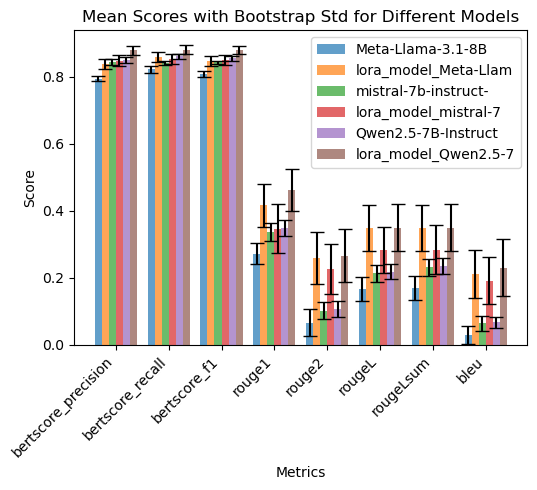

In [127]:
import numpy as np
import matplotlib.pyplot as plt

def plot_grouped_bar_adjustable_width(results, save_path=None):
    """
    Given the results dictionary {model_name: {metric_name: (mean, std)}},
    create a grouped bar plot with error bars for each metric,
    adjusting the bar width dynamically based on the number of models.
    """
    models = list(results.keys())
    metrics = list(next(iter(results.values())).keys())

    means = {metric: [results[model][metric][0] for model in models] for metric in metrics}
    stds = {metric: [results[model][metric][1] for model in models] for metric in metrics}

    x = np.arange(len(metrics))  # Label locations
    width = max(0.1, 0.8 / len(models))  # Dynamically adjust width

    fig, ax = plt.subplots(figsize=(5.5, 5))

    for i, model in enumerate(models):
        ax.bar(x + i * width - (len(models) - 1) * width / 2,  # Centering bars
               [means[m][i] for m in metrics], width, 
               yerr=[stds[m][i] for m in metrics], capsize=5, label=model[:20], alpha=0.7)

    ax.set_xlabel('Metrics')
    ax.set_ylabel('Score')
    ax.set_title('Mean Scores with Bootstrap Std for Different Models')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, rotation=45, ha='right')
    ax.legend()
    plt.tight_layout()
    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches='tight', pad_inches=0)
    plt.show()

# Running the function with the dataset
plot_grouped_bar_adjustable_width(results_all_aggr, save_path='figures/tech2nontech.pdf')


In [122]:
def generate_latex_figure_table_transposed(results):
    """
    Given the results dictionary {model_name: {metric_name: (mean, std)}},
    generate and print LaTeX figure* table code with booktabs formatting,
    correctly escaped underscores, and a transposed layout.
    """
    models = list(results.keys())
    metrics = list(next(iter(results.values())).keys())

    # Properly escape underscores for LaTeX
    def escape_latex(s):
        return s.replace("_", "\\_")

    # Start LaTeX figure* and tabular with booktabs
    latex_code = "\\begin{figure*}[h]\n\\centering\n"
    latex_code += "\\begin{tabular}{l" + "c" * len(metrics) + "}\n"
    latex_code += "\\toprule\n"

    # Header row with metrics as columns
    latex_code += "Model & " + " & ".join([escape_latex(metric) for metric in metrics]) + " \\\\\n"
    latex_code += "\\midrule\n"

    # Data rows: Each model gets a row
    for model in models:
        row = escape_latex(model)[:20] + " & " + " & ".join(
            [f"$ {results[model][metric][0]:.3f}$" for metric in metrics] #\\pm {results[model][metric][1]:.3f} 
        ) + " \\\\\n"
        latex_code += row
    
    # End LaTeX tabular and figure*
    latex_code += "\\bottomrule\n\\end{tabular}\n"
    latex_code += "\\caption{Mean scores with bootstrap standard deviations.}\n"
    latex_code += "\\label{fig:results}\n"
    latex_code += "\\end{figure*}"

    print(latex_code)

# Running the function with the dataset
generate_latex_figure_table_transposed(results_all_aggr)


\begin{figure*}[h]
\centering
\begin{tabular}{lcccccccc}
\toprule
Model & bertscore\_precision & bertscore\_recall & bertscore\_f1 & rouge1 & rouge2 & rougeL & rougeLsum & bleu \\
\midrule
Meta-Llama-3.1-8B & $ 0.795$ & $ 0.823$ & $ 0.808$ & $ 0.272$ & $ 0.067$ & $ 0.168$ & $ 0.169$ & $ 0.031$ \\
lora\_model\_Meta-Ll & $ 0.839$ & $ 0.859$ & $ 0.849$ & $ 0.417$ & $ 0.260$ & $ 0.349$ & $ 0.349$ & $ 0.212$ \\
mistral-7b-instruct- & $ 0.845$ & $ 0.843$ & $ 0.843$ & $ 0.337$ & $ 0.103$ & $ 0.215$ & $ 0.231$ & $ 0.064$ \\
lora\_model\_mistral & $ 0.849$ & $ 0.853$ & $ 0.851$ & $ 0.347$ & $ 0.226$ & $ 0.284$ & $ 0.285$ & $ 0.191$ \\
Qwen2.5-7B-Instruct & $ 0.851$ & $ 0.862$ & $ 0.856$ & $ 0.350$ & $ 0.107$ & $ 0.218$ & $ 0.236$ & $ 0.067$ \\
lora\_model\_Qwen2.5 & $ 0.879$ & $ 0.881$ & $ 0.880$ & $ 0.462$ & $ 0.266$ & $ 0.350$ & $ 0.350$ & $ 0.231$ \\
\bottomrule
\end{tabular}
\caption{Mean scores with bootstrap standard deviations.}
\label{fig:results}
\end{figure*}


In [35]:
!pip install tabulate

In [36]:
import pandas as pd

def create_markdown_table(results):
    """
    Given the results dictionary {model_name: {metric_name: (mean, std)}},
    create a markdown table showing only the mean values.
    """
    models = list(results.keys())
    metrics = list(next(iter(results.values())).keys())

    # Constructing the table data
    data = {metric: [results[model][metric][0] for model in models] for metric in metrics}
    df = pd.DataFrame(data, index=models)

    # Convert to markdown format
    markdown_table = df.to_markdown()
    
    return markdown_table

# Generate the markdown table
markdown_table = create_markdown_table(results_all_aggr)

# Display the markdown table
print(markdown_table)

|                                                                                               |   bertscore_precision |   bertscore_recall |   bertscore_f1 |   rouge1 |   rouge2 |   rougeL |   rougeLsum |      bleu |
|:----------------------------------------------------------------------------------------------|----------------------:|-------------------:|---------------:|---------:|---------:|---------:|------------:|----------:|
| mistral-7b-instruct-v0.3                                                                      |              0.862381 |           0.839548 |       0.850542 | 0.319412 | 0.071155 | 0.192979 |    0.198449 | 0.0333033 |
| lora_model_mistral-7b-instruct-v0.3_r16_la16_lr1e-05_e5_s-1_wu100_bs2_schlinear_optadamw_8bit |              0.86541  |           0.852586 |       0.858769 | 0.348234 | 0.116143 | 0.230632 |    0.230632 | 0.0629194 |
| lora_model_mistral-7b-instruct-v0.3_lr5e-05_e3_s-1_wu100_bs2_schlinear_optadamw_8bit          |              0.87132  |   

# Examples

In [5]:
from unsloth import FastLanguageModel
import sys
sys.path.append('../src')
# alpaca_prompt = Copied from above
from data_utils import alpaca_prompt, instructions_dict
from model_utils import get_model

ROOT_DIR = '/shared_data0/weiqiuy/nsf-awards'
debug = True

# model_name = 'unsloth/Qwen2.5-7B'
model_name = 'unsloth/mistral-7b-instruct-v0.3'
model, tokenizer = get_model(model_name, mode='eval')

model_name_lora = f'{ROOT_DIR}/models/lora_model_{model_name.split("/")[1]}'
model_lora, tokenizer = get_model(model_name_lora, mode='eval')



==((====))==  Unsloth 2025.1.7: Fast Mistral patching. Transformers: 4.48.1.
   \\   /|    GPU: NVIDIA RTX A6000. Max memory: 47.428 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.4.0+cu118. CUDA: 8.6. CUDA Toolkit: 11.8. Triton: 3.0.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.27.post2+cu118. FA2 = False]
 "-____-"     Free Apache license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
==((====))==  Unsloth 2025.1.7: Fast Mistral patching. Transformers: 4.48.1.
   \\   /|    GPU: NVIDIA RTX A6000. Max memory: 47.428 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.4.0+cu118. CUDA: 8.6. CUDA Toolkit: 11.8. Triton: 3.0.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.27.post2+cu118. FA2 = False]
 "-____-"     Free Apache license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Unsloth 2025.1.7 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


NameError: name 'test_dataset' is not defined

In [8]:
from data_utils import get_nsf_data_proc

train_dataset, val_dataset, test_dataset = get_nsf_data_proc(ROOT_DIR, tokenizer, mode='tech2nontech_instruct_user_assistant')

Train dataset keys: dict_keys(['award_id', 'technical_abstract', 'non_technical_abstract', 'verifiable_claims', 'investigation_proposals', 'award_year', 'division', 'directorate', 'title', 'publications'])
Validation dataset keys: dict_keys(['award_id', 'technical_abstract', 'non_technical_abstract', 'verifiable_claims', 'investigation_proposals', 'award_year', 'division', 'directorate', 'title', 'publications'])
Test dataset keys: dict_keys(['award_id', 'technical_abstract', 'non_technical_abstract', 'verifiable_claims', 'investigation_proposals', 'award_year', 'division', 'directorate', 'title', 'publications'])


Map:   0%|          | 0/8641 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [21]:
# FastLanguageModel.for_inference(model) # Enable native 2x faster inference
inputs = tokenizer(val_dataset[0]['text'], return_tensors = "pt").to("cuda")

outputs = model.generate(**inputs, max_new_tokens = 500, use_cache = True)
# pred = tokenizer.batch_decode(outputs)[0].split('### Response:')[1].strip()
pred = tokenizer.batch_decode(outputs)[0].replace(val_dataset[0]['text'], '')
pred

'<s> The technical abstract is:\n\nThe research will focus on the development of a novel 3D-printing  technique for the fabrication of complex micro- and nanostructures  in silicon carbide (SiC) and diamond. The proposed 3D-printing  technique is based on the use of a hybrid ink consisting of  nanoparticles of SiC and diamond suspended in a solvent. The  ink will be deposited using a modified fused filament fabrication  (FFF) 3D-printer, which will be optimized for the specific  requirements of the SiC and diamond nanoparticles. The  micro- and nanostructures fabricated using this technique will  be characterized using a variety of techniques, including  scanning electron microscopy (SEM), transmission electron  microscopy (TEM), and Raman spectroscopy. The research will  also investigate the effects of the printing parameters on the  microstructure and properties of the printed structures.\n\nPlease give me the NON-TECHNICAL ABSTRACT alone without other information.\n\nThe research ai

In [23]:
# FastLanguageModel.for_inference(model) # Enable native 2x faster inference
inputs = tokenizer(val_dataset[0]['text'], return_tensors = "pt").to("cuda")

outputs_lora = model_lora.generate(**inputs, max_new_tokens = 500, use_cache = True)
# pred = tokenizer.batch_decode(outputs)[0].split('### Response:')[1].strip()
pred_lora = tokenizer.batch_decode(outputs_lora)[0].replace(val_dataset[0]['text'], '')
pred_lora

'<s> This research program is directed at developing a  fundamental understanding of the growth and processing of  wide-bandgap semiconductor materials.  The materials system of  interest is the AlGaInN quaternary and related ternary and  binary alloys.  The primary goal of this program is to develop  a fundamental-understanding of the epitaxial growth, processing,  and properties of these materials so that they can be exploited  in the realization of a variety of advanced electronic and  photonic devices.  This research program is strongly coupled to  direct collaborative efforts with US optoelectronic industrial  research and development groups.  An important feature of the  program is the training of graduate and undergraduate students  in a fundamentally and technologically significant area of  materials and processing research.  This research will  contribute to improving the general performance of advanced  devices and integrated circuits used in computing,  information processin

In [24]:
val_dataset[0]['non_technical_abstract']

'The primary goal of this program is to develop a  fundamental-understanding of the epitaxial growth, processing,  and properties of wide bandgap semiconductor materials so that  they can be exploited in the realization of a variety of advanced  electronic and photonic devices. This research program is  strongly coupled to direct collaborative efforts with US  optoelectronic industrial research and development groups.  An  important feature of the program is the training of graduate and  undergraduate students in a fundamentally and technologically  significant area of materials and processing research.  This  research will contribute to improving the general performance of  advanced devices and integrated circuits used in computing,  information processing, and telecommunications.'

In [20]:
val_dataset[0]['technical_abstract']

'Research will be carried out to develop a fundamental  understanding of conventional and low temperature metalorganic  chemical vapor epitaxial materials growth and novel device  processing techniques for wide-bandgap III-V compound  semiconductors in the system consisting of the AlGaInN quaternary  and related ternary and binary alloys.  Lattice-matched and  intentionally lattice-mismatched heteroepitaxial heterostructures  will be grown in this materials system using both low-pressure  metalorganic chemical vapor deposition, and low-temperature  epitaxial growth by flow-rate modulation.  In addition, this  program will study the fundamental structural, electronic, and  optical materials properties, as well as the heterojunction band  alignments of these materials.'

In [27]:
# test

# FastLanguageModel.for_inference(model) # Enable native 2x faster inference
inputs = tokenizer(test_dataset[0]['text'], return_tensors = "pt").to("cuda")

outputs = model.generate(**inputs, max_new_tokens = 500, use_cache = True)
# pred = tokenizer.batch_decode(outputs)[0].split('### Response:')[1].strip()
pred = tokenizer.batch_decode(outputs)[0].replace(test_dataset[0]['text'], '')
pred

'<s> The objective of the investigation is to study the properties of sulfide glasses, specifically focusing on their glass-forming ranges, densities, glass transition temperatures, ionic conductivities, and infrared transmission spectra. These glasses will be prepared in controlled laboratory conditions to minimize the presence of oxygen and water vapor. The properties of these glasses will be determined using various techniques, including direct current electrical conductivity, differential scanning calorimetry, Fourier Transform Infrared Spectroscopy, and nuclear magnetic resonance. The structure of these glasses will be compared to their oxide counterparts.\n\nIn simpler terms, the research aims to explore the characteristics of sulfide glasses, such as their ability to form glass, their density, the temperature at which they transition from a solid to a liquid, their ability to conduct ions, and how they transmit infrared light. These glasses will be made in a controlled lab envir

In [28]:
# FastLanguageModel.for_inference(model) # Enable native 2x faster inference
inputs = tokenizer(test_dataset[0]['text'], return_tensors = "pt").to("cuda")

outputs_lora = model_lora.generate(**inputs, max_new_tokens = 500, use_cache = True)
# pred = tokenizer.batch_decode(outputs)[0].split('### Response:')[1].strip()
pred_lora = tokenizer.batch_decode(outputs_lora)[0].replace(test_dataset[0]['text'], '')
pred_lora

'<s> Undergraduate students will be recruited from the University of Texas at Austin and other local colleges and universities. The students will be involved in all aspects of the research, including the synthesis and characterization of the glasses. The students will be encouraged to present their work at local, regional, and national meetings.</s>'

In [29]:
test_dataset[0]['non_technical_abstract']

'The request includes a Research Experience for Undergraduates Supplement, which will enable two undergraduate students to participate in the study. It is hoped that this hands-on experience will serve as a stimulus to attract highly-gifted students into teaching and research careers, as well as to contribute to the overall goals of this program. There is renewed scientific and technological interest in the glasses in this general composition range because of their potential commercial application in low loss, infrared fiber waveguides for optical communications and optical data processing.'

In [30]:
test_dataset[0]['technical_abstract']

'The objective of the investigation is to study the glass-forming ranges, densities, glass transition temperatures, ionic conductivities, and infrared transmission spectra of sulfide glass systems. Alkali and silver sulfide, aluminum sulfide, and boron and phosphorous sulfide glasses will be prepared in controlled ambient conditions to eliminate oxygen and water vapor. The physical properties will be determined using direct current electrical conductivity, differential scanning calorimetry, Fourier Transform Infrared Spectroscopy, and nuclear magnetic resonance. The structure of these glasses will be compared to their oxide analogues.'